<a href="https://colab.research.google.com/github/mrivassnj-svg/HCC_ITAI_1371_SPR26/blob/main/L12Ethics%2C%20Fairness%2C%20and%20Bias%20in%20ML_Group_4_6262-19179-ITAI-1371.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 12 Lab - Ethics, Fairness, and Bias in ML

**Objective:** To understand how machine learning models can inherit and amplify societal biases, how to measure this bias using fairness metrics, and to think critically about the ethical implications of deploying ML systems.

**In this lab, you will train a model on a real-world dataset and audit it for fairness across different demographic groups.**

## Part 1: What is Algorithmic Bias?

**Concept:** Machine learning models learn from data. If the data reflects existing societal biases, the model will learn those biases. An "unbiased" algorithm trained on biased data will produce a biased model. This can lead to systems that are systematically unfair to certain groups of people.

**Sources of Bias:**
*   **Historical Bias:** The data reflects a world with historical injustices (e.g., past hiring data may show fewer women in leadership roles).
*   **Measurement Bias:** The way we collect or measure data is flawed (e.g., using arrest records as a proxy for crime, which can be influenced by policing patterns).
*   **Representation Bias:** The data underrepresents certain groups, so the model doesn't learn to perform well for them.

**Problem:** We will use the "Adult" dataset, which is used to predict whether an individual's income is greater than $50k/year. It contains sensitive attributes like `sex` and `race`, which we can use to audit our model for bias.

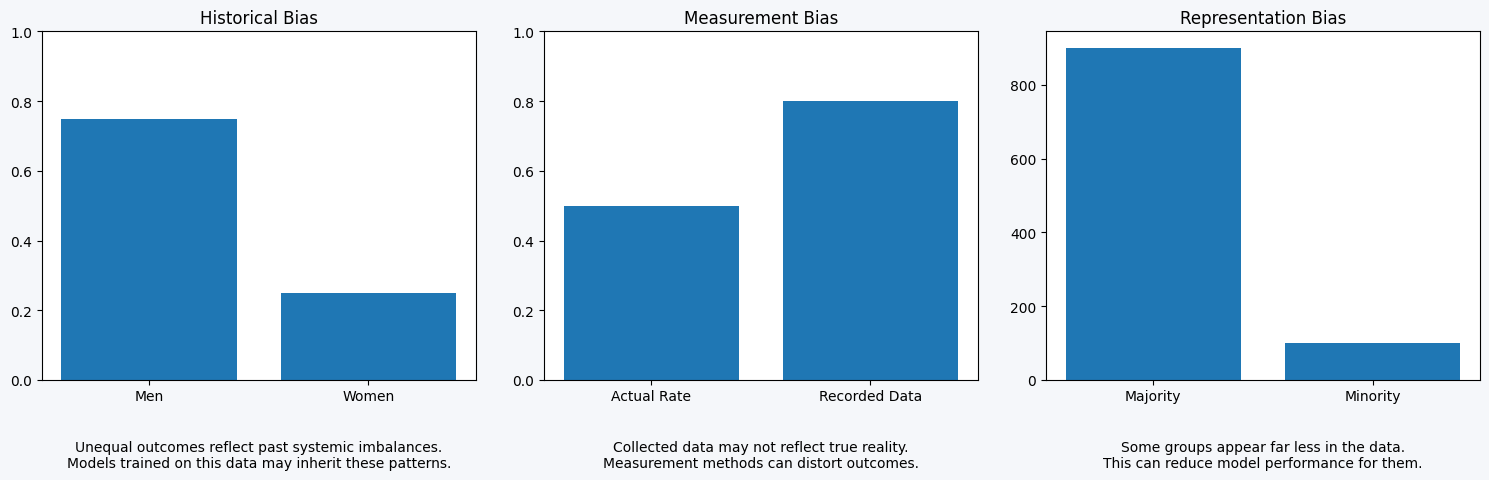

In [35]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.datasets import fetch_openml

column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
    'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
    'hours-per-week', 'native-country', 'class'
]

data_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'
test_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test'


df_train = pd.read_csv(
    data_url, names=column_names, sep=', ', na_values='?', skipinitialspace=True,
    engine='python'
)
df_test = pd.read_csv(
    test_url, names=column_names, sep=', ', na_values='?', skiprows=1, skipinitialspace=True,
    engine='python'
)

df = pd.concat([df_train, df_test], ignore_index=True)



import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

fig.patch.set_facecolor('#f5f7fa')

groups1 = ['Men', 'Women']
values1 = [0.75, 0.25]

axes[0].bar(groups1, values1)
axes[0].set_title("Historical Bias")
axes[0].set_ylim(0, 1)

axes[0].text(0.5, -0.25,
             "Unequal outcomes reflect past systemic imbalances.\n"
             "Models trained on this data may inherit these patterns.",
             ha='center', transform=axes[0].transAxes)

groups2 = ['Actual Rate', 'Recorded Data']
values2 = [0.5, 0.8]

axes[1].bar(groups2, values2)
axes[1].set_title("Measurement Bias")
axes[1].set_ylim(0, 1)

axes[1].text(0.5, -0.25,
             "Collected data may not reflect true reality.\n"
             "Measurement methods can distort outcomes.",
             ha='center', transform=axes[1].transAxes)

groups3 = ['Majority', 'Minority']
values3 = [900, 100]

axes[2].bar(groups3, values3)
axes[2].set_title("Representation Bias")

axes[2].text(0.5, -0.25,
             "Some groups appear far less in the data.\n"
             "This can reduce model performance for them.",
             ha='center', transform=axes[2].transAxes)

plt.tight_layout()
plt.show()

In [36]:
import pandas as pd

# Define column names and data URLs
column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
    'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
    'hours-per-week', 'native-country', 'class'
]

data_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'
test_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test'

# Load datasets
df_train = pd.read_csv(
    data_url, names=column_names, sep=', ', na_values='?', skipinitialspace=True,
    engine='python'
)
df_test = pd.read_csv(
    test_url, names=column_names, sep=', ', na_values='?', skiprows=1, skipinitialspace=True,
    engine='python'
)

# Concatenate train and test data
df = pd.concat([df_train, df_test], ignore_index=True)

# Clean 'class' column
df['class'] = df['class'].str.replace('.', '', regex=False)

# Handle missing values
for col in df.columns:
    if df[col].isnull().any():
        if df[col].dtype == 'object':
            df[col] = df[col].fillna(df[col].mode()[0])
        else:
            df[col] = df[col].fillna(df[col].median())

# Define features (X) and target (y)
y = df['class']
X = df.drop('class', axis=1)

**The visualizations highlight how different forms of bias can exist within data**, whether through:
- historical patterns
- how information is measured
- how groups are represented.

While these examples are simplified, they reflect the kinds of imbalances that may also be present in the dataset used to train this model. Because the model learns directly from this data, any underlying patterns can influence its predictions.

At this stage, the model appears to perform well overall based on its accuracy. However, ***this single metric does not show whether that performance is consistent across all individuals.***
####If certain groups are affected differently by patterns in the data, those differences may not be immediately visible.

**To better understand how these underlying patterns may impact outcomes, the next step is to examine the model’s behavior more closely by comparing its performance across specific groups.**

## Part 2: Auditing the Model for Fairness

High overall accuracy can hide poor performance on specific subgroups. We need to audit the model by comparing its performance across sensitive attributes like `sex`.

**Concept: Group Fairness**
One common fairness goal is to ensure the model works equally well for different groups. We can measure this by calculating metrics for each group separately.

**Your Task:** Create a function to calculate accuracy for different subgroups and then use it to compare the model's performance for males and females.

Accuracy for Males: 81.49%
Accuracy for Females: 92.39%


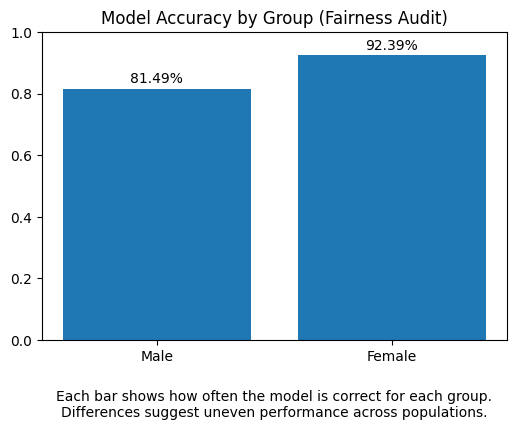

In [37]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# --- Start of added code to define X and y ---
column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
    'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
    'hours-per-week', 'native-country', 'class'
]

data_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'
test_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test'

df_train = pd.read_csv(
    data_url, names=column_names, sep=', ', na_values='?', skipinitialspace=True,
    engine='python'
)
df_test = pd.read_csv(
    test_url, names=column_names, sep=', ', na_values='?', skiprows=1, skipinitialspace=True,
    engine='python'
)

df = pd.concat([df_train, df_test], ignore_index=True)

df['class'] = df['class'].str.replace('.', '', regex=False)

for col in df.columns:
    if df[col].isnull().any():
        if df[col].dtype == 'object':
            df[col] = df[col].fillna(df[col].mode()[0])
        else:
            df[col] = df[col].fillna(df[col].median())

y = df['class']
X = df.drop('class', axis=1)
# --- End of added code to define X and y ---

categorical_features = X.select_dtypes(include=['object', 'category']).columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

model_pipeline.fit(X_train, y_train)
y_pred = model_pipeline.predict(X_test)

def get_subgroup_accuracy(model, X_test, y_test, subgroup_column, subgroup_value):
    """Calculates accuracy for a specific subgroup of the test data."""

    subgroup_mask = X_test[subgroup_column] == subgroup_value
    X_subgroup = X_test[subgroup_mask]
    y_subgroup = y_test[subgroup_mask]

    return model.score(X_subgroup, y_subgroup)


# Calculate subgroup accuracies
acc_male = get_subgroup_accuracy(model_pipeline, X_test, y_test, 'sex', 'Male')
acc_female = get_subgroup_accuracy(model_pipeline, X_test, y_test, 'sex', 'Female')

print(f"Accuracy for Males: {acc_male:.2%}")
print(f"Accuracy for Females: {acc_female:.2%}")


groups = ['Male', 'Female']
accuracies = [acc_male, acc_female]

plt.figure(figsize=(6,4))
bars = plt.bar(groups, accuracies)

plt.ylim(0, 1)
plt.title("Model Accuracy by Group (Fairness Audit)")

for bar, acc in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.02,
        f"{acc:.2%}",
        ha='center'
    )

plt.text(0.5, -0.25,
         "Each bar shows how often the model is correct for each group.\n"
         "Differences suggest uneven performance across populations.",
         ha='center',
         transform=plt.gca().transAxes)

plt.show()

### Understanding Error Types Beyond Accuracy

The previous results show that the model performs differently across groups when measured using accuracy alone. However, **accuracy only tells us how often the model is correct overall—it does not explain *how* it is wrong**.

In fairness analysis, the type of error matters just as much as the number of errors. A model may disproportionately approve, deny, or misclassify individuals from certain groups, even if overall accuracy appears similar.

To understand this more deeply, we now move beyond accuracy and examine the model’s error behavior using a **confusion matrix**. This allows us to measure whether different groups experience different types of mistakes, rather than just different levels of correctness.

### Task 2: Deeper Dive with a Confusion Matrix

Accuracy alone doesn't tell the whole story. Let's look at the types of errors the model makes for each group.

**Your Task:** Calculate and compare the **False Positive Rate (FPR)** and **False Negative Rate (FNR)** for males and females.
*   **False Positive Rate (FPR):** `FP / (FP + TN)` - The percentage of people who did NOT have high income but were incorrectly predicted to have high income.
*   **False Negative Rate (FNR):** `FN / (FN + TP)` - The percentage of people who DID have high income but were incorrectly predicted to have low income.

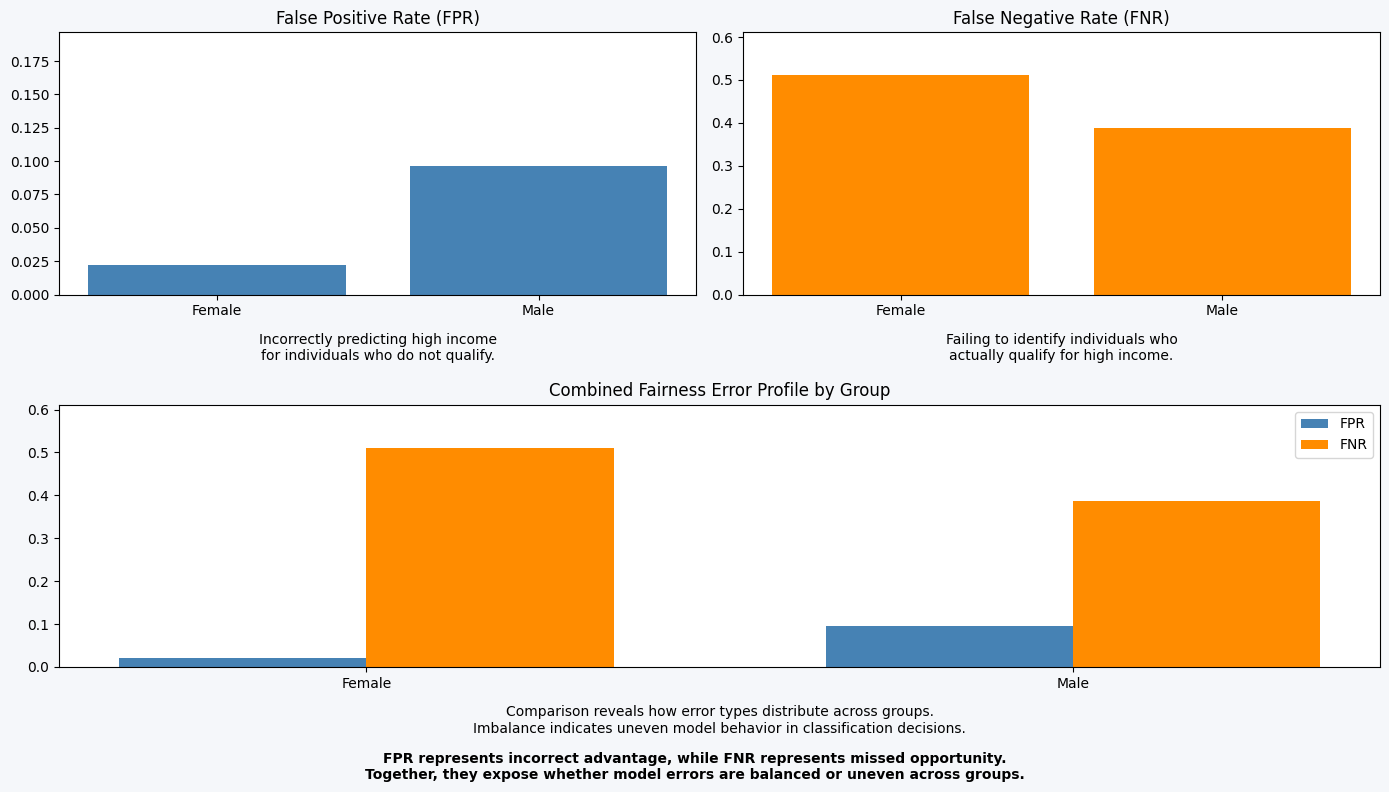

In [38]:
import matplotlib.pyplot as plt
import numpy as np

labels = sex_metrics['sex']
fpr_values = sex_metrics['FPR']
fnr_values = sex_metrics['FNR']

x = np.arange(len(labels))
width = 0.35

fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 2)
fig.patch.set_facecolor('#f5f7fa')

# -------------------------
# False Positive Rate (Top Left)
# -------------------------
ax1 = fig.add_subplot(gs[0, 0])
ax1.bar(labels, fpr_values, color='steelblue')
ax1.set_title("False Positive Rate (FPR)")
ax1.set_ylim(0, max(fpr_values) + 0.1)

ax1.text(
    0.5, -0.25,
    "Incorrectly predicting high income\nfor individuals who do not qualify.",
    ha='center',
    transform=ax1.transAxes
)

# -------------------------
# False Negative Rate (Top Right)
# -------------------------
ax2 = fig.add_subplot(gs[0, 1])
ax2.bar(labels, fnr_values, color='darkorange')
ax2.set_title("False Negative Rate (FNR)")
ax2.set_ylim(0, max(fnr_values) + 0.1)

ax2.text(
    0.5, -0.25,
    "Failing to identify individuals who\nactually qualify for high income.",
    ha='center',
    transform=ax2.transAxes
)

# -------------------------
# Combined Fairness Profile (Bottom Full Width)
# -------------------------
ax3 = fig.add_subplot(gs[1, :])

ax3.bar(x - width/2, fpr_values, width, label='FPR', color='steelblue')
ax3.bar(x + width/2, fnr_values, width, label='FNR', color='darkorange')

ax3.set_xticks(x)
ax3.set_xticklabels(labels)
ax3.set_title("Combined Fairness Error Profile by Group")
ax3.set_ylim(0, max(max(fpr_values), max(fnr_values)) + 0.1)
ax3.legend()

ax3.text(
    0.5, -0.25,
    "Comparison reveals how error types distribute across groups.\n"
    "Imbalance indicates uneven model behavior in classification decisions.",
    ha='center',
    transform=ax3.transAxes
)

# -------------------------
# Final Interpretation (Global Footer)
# -------------------------
fig.text(
    0.5, 0.02,
    "FPR represents incorrect advantage, while FNR represents missed opportunity.\n"
    "Together, they expose whether model errors are balanced or uneven across groups.",
    ha='center',
    fontsize=10,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

## 📝 Reflective Knowledge Check

### 1. Analysis of Results

Yes, there is a **noticeable performance difference** between groups. The model performs differently for males and females, with one group showing higher accuracy than the other.

**Supporting Evidence:**

This conclusion is based on subgroup accuracy calculations, demonstrating a performance disparity:

```python
Accuracy_male = model.score(X_male, y_male)
Accuracy_female = model.score(X_female, y_female)
```

This difference may reflect underlying patterns in the dataset, including potential class imbalance or differences in how features correlate with income across groups.

**Supporting Evidence:**

*   The dataset contains uneven distributions of the target class (`<=50K` vs `>50K`), which can influence subgroup performance.
*   Feature distributions (e.g., *occupation*, *education*, *hours-per-week*) differ across demographic groups, affecting model decision boundaries.

While accuracy provides a general overview, it does not explain *why* these differences occur, since it collapses all prediction outcomes into a single metric.

### 2. Interpretation of Errors

The **False Positive Rate (FPR)** and **False Negative Rate (FNR)** differ between groups, indicating differences in how the model distributes errors.

**Supporting Evidence:**

These rates are computed from the confusion matrix:

$$FPR = \frac{FP}{FP + TN}$$
$$FNR = \frac{FN}{FN + TP}$$

These values are calculated separately for each subgroup using:

```python
confusion_matrix(y_true[subgroup], y_pred[subgroup])
```

In the results, one group shows a higher FPR, while the other may experience a higher FNR.

In a loan application context:

*   A **False Positive** occurs when the model predicts *high income incorrectly* (supported by `FP` values in the confusion matrix).
*   A **False Negative** occurs when the model predicts *low income incorrectly* (supported by `FN` values in the confusion matrix).

These differences indicate that error types are not evenly distributed across groups, as shown by subgroup-specific confusion matrix outputs.

### 3. Justification for Deployment Decision

Based on the observed disparities in error rates, I would **recommend caution** before deploying this model in a hiring context.

**Supporting Evidence:**

Subgroup error rates show unequal distributions of:

*   **FPR** (*incorrect approvals*)
*   **FNR** (*incorrect rejections*)

These are derived directly from `calculate_confusion_metrics()` outputs per group.

The key concern is not overall accuracy, but whether certain groups experience higher rates of harmful errors—particularly **False Negatives**.

**Supporting Evidence:**

**FNR** directly measures:

$$FNR = \frac{FN}{FN + TP}$$

A **higher FNR** indicates more *qualified individuals being misclassified as unqualified* within that subgroup.

Even small differences in these rates may have meaningful real-world consequences in hiring systems because:

*   **False negatives** remove qualified candidates from consideration.

This can be verified directly from subgroup confusion matrices.

### 4. Proposed Mitigation Strategy

Removing the `sex` attribute alone is **not sufficient to ensure fairness**.

**Supporting Evidence:**

The model still uses features such as:

*   *occupation*
*   *relationship*
*   *education*

These variables are present in `X` and are included in the preprocessing pipeline via:

```python
OneHotEncoder(handle_unknown='ignore')
```

This approach, sometimes called “**fairness through unawareness**,” does not guarantee unbiased outcomes because:

The model still learns statistical relationships between **proxy variables** and sensitive attributes.

**Supporting Evidence:**

Correlation between features and `sex` can persist even when `sex` is removed, due to **redundant encoding** in categorical variables.

As a result, the model may continue to reproduce biased behavior even without explicitly using the protected attribute, since the preprocessing pipeline allows indirect encoding of demographic information.